# Data Science Practice
## From Messy Data to Predictive Model

**Instructor:** Abishek Ganesh  
**Date:** December 11, 2025

---

**Required Files:** To run this notebook, you'll need the following CSV files from the datasets folder in Google Drive:
- `used_sedans.csv`
- `used_trucks.csv`
- `trucks_validation.csv` (provided after breakout rooms)

---

Today we'll practice the nearly the **complete data science workflow**:
1. Load data
2. Explore & understand
3. Clean the data
4. Feature engineering
5. Build a model
6. Evaluate
7. Iterate

**Part A:** Guided walkthrough together (Used Sedans)

**Part B:** Breakout competition - you build your own model! (Used Trucks)

---
# Part A: Guided Walkthrough
## Predicting Used Sedan Prices

We have a dataset of used sedan cars. Our goal: **predict the price** based on the car's features.

### Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import coremltools as ct

### Step 2: Load and Explore the Data

In [3]:
# Load the data
df = pd.read_csv('./used_sedans.csv')

# First look at our data
df.head(10)

ModuleNotFoundError: No module named 'pandas.io.formats.string'

ModuleNotFoundError: No module named 'pandas.io.formats.html'

In [3]:
# Check the shape
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Dataset shape: (52, 4)
Rows: 52, Columns: 4


In [4]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          52 non-null     int64  
 1   Mileage       48 non-null     float64
 2   Transmission  52 non-null     object 
 3   Price         52 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.8+ KB


**What do we notice?**
- Mileage has some missing values
- Price is stored as a string (object type) - we need to fix this!
- Transmission has inconsistent values

### Step 3: Data Cleaning

Let's fix the issues we found!

#### 3a. Check for Duplicates

In [5]:
# How many duplicate rows?
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 2


In [ ]:
# Remove duplicates
df = df.drop_duplicates()

print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (50, 4)


**Why remove duplicates?** Duplicate rows can trick our model into thinking certain patterns are more common than they actually are. It's like counting the same car twice - it would skew our predictions.

#### 3b. Handle Missing Values

In [7]:
# Check missing values per column
print("Missing values:")
print(df.isnull().sum())

Missing values:
Year            0
Mileage         4
Transmission    0
Price           0
dtype: int64


In [8]:
# For simplicity, let's drop rows with missing mileage
# (In real projects, you might fill with median or mean)
df = df.dropna(subset=['Mileage'])

print(f"Shape after dropping missing values: {df.shape}")
print(f"Missing values now: {df.isnull().sum().sum()}")

Shape after dropping missing values: (46, 4)
Missing values now: 0


**Why handle missing values?** Machine learning models can't do math with empty cells. We either need to fill them in (imputation) or remove those rows. For now, we're keeping it simple and dropping them.

#### 3c. Fix Price Column (Remove $ and commas)

In [9]:
# Look at the Price column
print("Price column (before cleaning):")
print(df['Price'].head())
print(f"\nData type: {df['Price'].dtype}")

Price column (before cleaning):
0    $22,500
1    $19,800
2    $16,500
3    $24,000
4    $14,200
Name: Price, dtype: object

Data type: object


In [10]:
# Remove $ and commas, convert to number
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = df['Price'].astype(float)

print("Price column (after cleaning):")
print(df['Price'].head())
print(f"\nData type: {df['Price'].dtype}")

Price column (after cleaning):
0    22500.0
1    19800.0
2    16500.0
3    24000.0
4    14200.0
Name: Price, dtype: float64

Data type: float64


**Why convert Price to numbers?** To Python, "$22,500" is just text (a string), not a number. You can't do math on text! We need to strip out the $ and commas so Python sees it as the number 22500.

#### 3d. Standardize Transmission Column

In [11]:
# Check unique values in Transmission
print("Unique Transmission values:")
print(df['Transmission'].unique())

Unique Transmission values:
['automatic' 'Auto' 'auto' 'manual' 'Manual']


In [12]:
# Convert all to lowercase
df['Transmission'] = df['Transmission'].str.lower()

print("After standardizing:")
print(df['Transmission'].unique())

After standardizing:
['automatic' 'auto' 'manual']


**Why standardize text?** To Python, "Auto", "auto", and "automatic" are three different values. By converting everything to lowercase, we ensure consistent categories.

In [13]:
# Check our cleaned data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 0 to 51
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          46 non-null     int64  
 1   Mileage       46 non-null     float64
 2   Transmission  46 non-null     object 
 3   Price         46 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.8+ KB


### Step 4: Feature Engineering

**What is feature engineering?** Creating new columns from existing data that might help our model make better predictions.

Let's create a new feature: **Age** (how old is the car?)

**Why Age instead of Year?**
- Year = 2020 doesn't directly tell the model "this car is 4 years old"
- Age = 4 is more meaningful - it directly represents how old the car is
- The model can more easily learn: "older cars = lower price"

In [19]:
# Calculate car age (current year - car year)
current_year = 2025
df['Age'] = current_year - df['Year']

print("New Age column:")
df[['Year', 'Age']].head(10)

New Age column:


,Year,Age
0,2020,5
1,2019,6
2,2018,7
3,2021,4
4,2017,8
5,2020,5
6,2019,6
7,2022,3
8,2018,7
9,2017,8


**What other features could we create?** Think about it:
- Miles per year? (Mileage / Age)
- Is it high mileage? (Mileage > 50000)
- Is it a newer car? (Age < 3)

Feature engineering is part art, part science - experiment and see what helps!

In [16]:
# View our final cleaned dataset
df.head(10)

,Year,Mileage,Transmission,Price,Age
0,2020,25000.0,automatic,22500.0,4
1,2019,35000.0,auto,19800.0,5
2,2018,48000.0,auto,16500.0,6
3,2021,18000.0,manual,24000.0,3
4,2017,62000.0,automatic,14200.0,7
5,2020,30000.0,manual,21500.0,4
6,2019,41000.0,auto,18900.0,5
7,2022,12000.0,automatic,27500.0,2
8,2018,55000.0,auto,15800.0,6
9,2017,70000.0,manual,13500.0,7


### Step 5: Quick Visualization

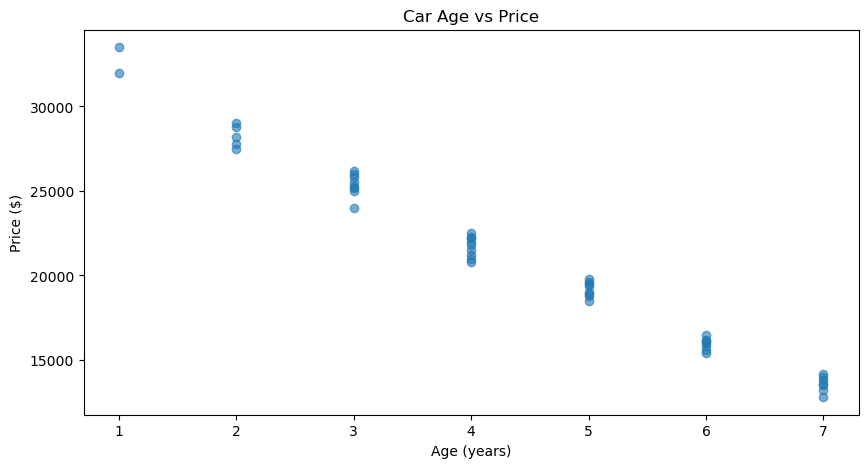

In [17]:
# Does Age affect Price?
plt.figure(figsize=(10, 5))
plt.scatter(df['Age'], df['Price'], alpha=0.6)
plt.xlabel('Age (years)')
plt.ylabel('Price ($)')
plt.title('Car Age vs Price')
plt.show()

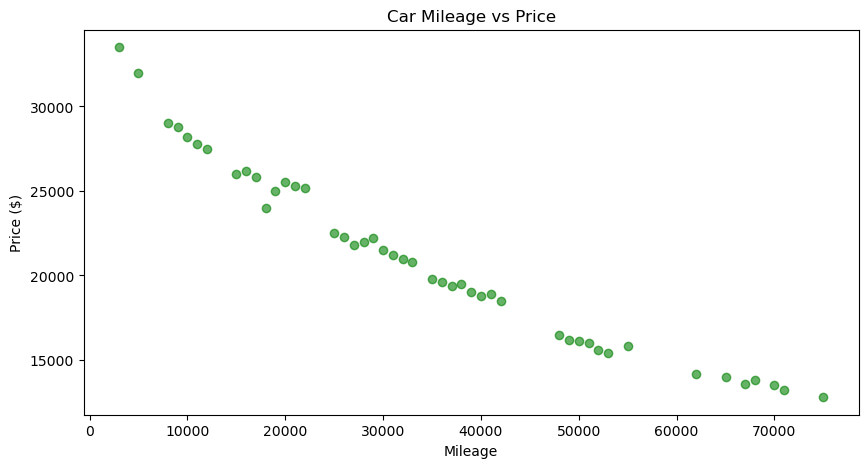

In [20]:
# Does Mileage affect Price?
plt.figure(figsize=(10, 5))
plt.scatter(df['Mileage'], df['Price'], alpha=0.6, color='green')
plt.xlabel('Mileage')
plt.ylabel('Price ($)')
plt.title('Car Mileage vs Price')
plt.show()

### Important: When Does Linear Regression Work?

Linear regression assumes a **linear relationship** (a straight line) between features and target.

But what happens when the relationship is **curved** (exponential)? Let's see!

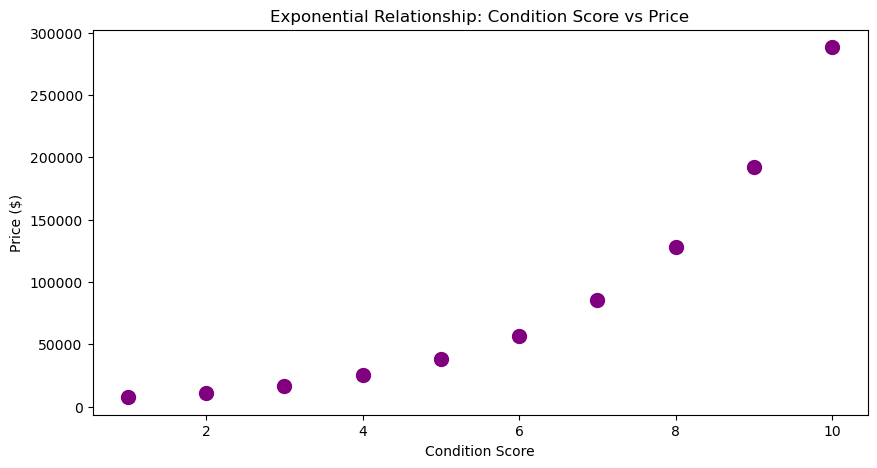

Notice: This is a CURVE, not a straight line!


In [21]:
# Let's create an example with EXPONENTIAL data
# Imagine: "Condition Score" (1-10) affects price exponentially
# A car in perfect condition (10) is worth way more than a car in okay condition (5)

condition_scores = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
# Exponential relationship: price grows exponentially with condition
exponential_prices = 5000 * (1.5 ** condition_scores)  # Exponential growth

# Visualize the exponential relationship
plt.figure(figsize=(10, 5))
plt.scatter(condition_scores, exponential_prices, s=100, color='purple')
plt.xlabel('Condition Score')
plt.ylabel('Price ($)')
plt.title('Exponential Relationship: Condition Score vs Price')
plt.show()

print("Notice: This is a CURVE, not a straight line!")

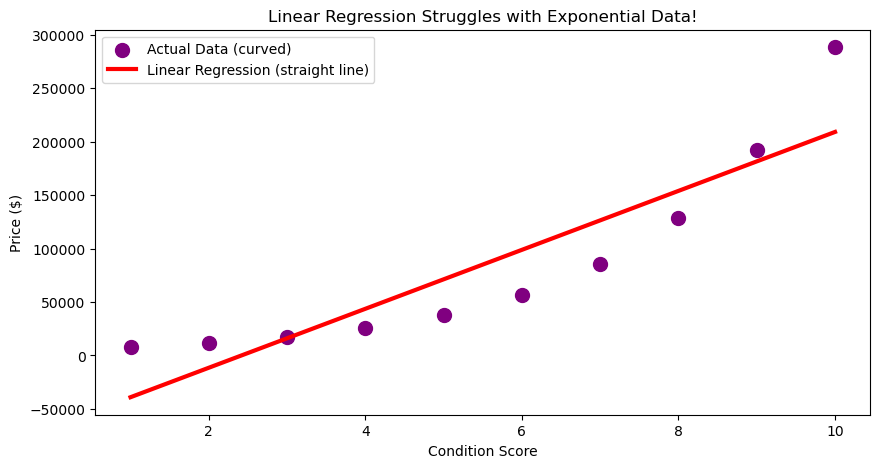

R² Score: 0.8111

The straight line can't capture the curve!


In [22]:
# Now let's try to fit Linear Regression to this curved data
X_exp = condition_scores.reshape(-1, 1)
y_exp = exponential_prices

# Train a linear regression model
exp_model = LinearRegression()
exp_model.fit(X_exp, y_exp)

# Make predictions
y_exp_pred = exp_model.predict(X_exp)

# Plot the result
plt.figure(figsize=(10, 5))
plt.scatter(condition_scores, exponential_prices, s=100, color='purple', label='Actual Data (curved)')
plt.plot(condition_scores, y_exp_pred, color='red', linewidth=3, label='Linear Regression (straight line)')
plt.xlabel('Condition Score')
plt.ylabel('Price ($)')
plt.title('Linear Regression Struggles with Exponential Data!')
plt.legend()
plt.show()

# Calculate R² score
exp_r2 = r2_score(y_exp, y_exp_pred)
print(f"R² Score: {exp_r2:.4f}")
print("\nThe straight line can't capture the curve!")

In [23]:
# Let's see how bad the prediction is for Condition Score = 6
condition_to_predict = 6

# What does the LINEAR model predict?
linear_prediction = exp_model.predict([[condition_to_predict]])[0]

# What is the ACTUAL price (from the exponential curve)?
actual_price = 5000 * (1.5 ** condition_to_predict)

print(f"Condition Score: {condition_to_predict}")
print(f"{'='*40}")
print(f"Linear Model Predicts:  ${linear_prediction:,.0f}")
print(f"Actual Price:           ${actual_price:,.0f}")
print(f"{'='*40}")
print(f"Difference:             ${abs(actual_price - linear_prediction):,.0f} OFF!")
print(f"\nThe linear model is way off because it can't follow the curve!")

Condition Score: 6
Linear Model Predicts:  $98,785
Actual Price:           $56,953
Difference:             $41,832 OFF!

The linear model is way off because it can't follow the curve!


**Key Takeaway:**

Linear Regression works best when the relationship between features and target is **roughly linear** (a straight line).

- **Good for:** Age vs Price, Mileage vs Price (roughly linear relationships)
- **Not ideal for:** Exponential, logarithmic, or other curved relationships

Our sedan data (Age, Mileage vs Price) looks fairly linear, so Linear Regression should work well!

*Later in the course, you'll learn about other models that can handle curved relationships.*

### Step 6: Build the Model

In [24]:
# Define features and target
X = df[['Age', 'Mileage']]
y = df['Price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (46, 2)
Target shape: (46,)


In [ ]:
# Split into train and test sets
# Define features and target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 36
Testing samples: 10


**Why split into train and test?** We train the model on 80% of the data, then test it on the remaining 20% that it's never seen. This tells us how well the model will perform on *new* data in the real world.

In [26]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


### Step 7: Evaluate the Model

In [27]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate R² score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.9535


**What does R² mean?**
- R² (R-squared) measures how well our model explains the variation in prices
- **R² = 0.85** means our model explains 85% of why car prices differ
- **R² = 1.0** would be perfect (impossible in real life!)
- **R² = 0.0** means the model is no better than just guessing the average price

The higher the R², the better our model is at predicting!

In [28]:
# View predictions vs actual
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred.round(0)
})
comparison['Difference'] = (comparison['Actual'] - comparison['Predicted']).round(0)
comparison

,Actual,Predicted,Difference
0,20800.0,22397.0,-1597.0
1,21200.0,22379.0,-1179.0
2,19600.0,19208.0,392.0
3,27800.0,28634.0,-834.0
4,25000.0,25489.0,-489.0
5,25300.0,25506.0,-206.0
6,14200.0,13006.0,1194.0
7,16000.0,16125.0,-125.0
8,15800.0,16160.0,-360.0
9,24000.0,25480.0,-1480.0


### Summary - Part A

We just completed the full data science workflow:
1. **Loaded** messy data
2. **Explored** to find issues
3. **Cleaned**: removed duplicates, handled missing values, fixed data types
4. **Engineered** a new feature (Age)
5. **Built** a Linear Regression model
6. **Evaluated** with R² score

Now it's YOUR turn!

---
# Part B: Breakout Competition!
## Build Your Own Used Truck Price Predictor

You have a dataset of **used trucks**. Your mission:
1. Clean the data
2. Engineer features
3. Build the best model you can

**Approach: Start Simple, Then Build Up!**
- First, try predicting with just ONE feature
- See your R² score
- Then add more features or edit existing features and see if it improves
- Keep experimenting!

**Competition Rules:**
- Everyone uses the same data
- You decide: which features to use, how to handle missing values, etc.
- Best R² score wins!

**After breakout rooms:** We'll test everyone's models on a **validation set** that you haven't seen yet. This will show how well your model works on brand new data!

### Step 1: Load the Truck Data

In [89]:
# Load the truck data
trucks = pd.read_csv('./used_trucks.csv')

# Take a look
trucks.head(10)

,Year,Mileage,Transmission,Bed_Length,Four_Wheel_Drive,Engine,Condition,Previous_Owners,Price
0,2020,35000.0,automatic,standard,Yes,V8,8,1.0,"$28,500"
1,2019,48000.0,Auto,long,no,V6,7,2.0,"$25,200"
2,2018,62000.0,auto,standard,YES,v8,6,2.0,"$21,800"
3,2021,22000.0,manual,short,No,V8,9,1.0,"$31,000"
4,2017,78000.0,automatic,standard,yes,V6,5,3.0,"$18,500"
5,2020,40000.0,Manual,long,Yes,v6,7,1.0,"$27,500"
6,2019,52000.0,auto,standard,NO,V8,6,2.0,"$24,500"
7,2022,15000.0,automatic,short,yes,V8,9,1.0,"$35,000"
8,2018,68000.0,Auto,standard,Yes,V6,5,3.0,"$20,500"
9,2017,85000.0,manual,long,no,v8,4,4.0,"$17,200"


In [90]:
# Explore the data - what issues do you see?
trucks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              60 non-null     int64  
 1   Mileage           56 non-null     float64
 2   Transmission      60 non-null     object 
 3   Bed_Length        60 non-null     object 
 4   Four_Wheel_Drive  60 non-null     object 
 5   Engine            60 non-null     object 
 6   Condition         60 non-null     int64  
 7   Previous_Owners   58 non-null     float64
 8   Price             60 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 4.3+ KB


### Step 2: Clean the Data

Fix the issues you found! (Hint: same issues as Part A)

In [91]:
# Remove duplicates

trucks = trucks.drop_duplicates()
print(f"Duplicate rows: {trucks.duplicated().sum()}")

Duplicate rows: 0


In [92]:
# Handle missing values
trucks = trucks.dropna(subset=['Mileage'])

In [93]:
# Fix the Price column
trucks['Price'] = trucks['Price'].str.replace('$', '', regex=False)
trucks['Price'] = trucks['Price'].str.replace(',', '', regex=False)
trucks['Price'] = trucks['Price'].astype(float)

print("Price column (after cleaning):")
print(trucks['Price'].head())
print(f"\nData type: {trucks['Price'].dtype}")

Price column (after cleaning):
0    28500.0
1    25200.0
2    21800.0
3    31000.0
4    18500.0
Name: Price, dtype: float64

Data type: float64


In [94]:
# Standardize any text columns if needed
trucks['Transmission'] = trucks['Transmission'].str.lower()
# trucks['Transmission'].unique()

current_year = 2025
trucks['Age'] = current_year - trucks['Year']

print("New Age column:")
trucks[['Year', 'Age']].head(10)

trucks['IS_HIGH_MILEAGE'] = trucks['Mileage'] > 50000

"""What other features could we create? Think about it:
Miles per year? (Mileage / Age)
Is it high mileage? (Mileage > 50000)
Is it a newer car? (Age < 3)
Feature engineering is part art, part science - experiment and see what helps! """


categorical_columns = ['Transmission', 'Bed_Length', 'Four_Wheel_Drive', 'Engine']
for col in categorical_columns:
    trucks[col] = trucks[col].str.lower()
print("After standardizing:")
print([trucks[col].unique() for col in categorical_columns])

trucks_encoded = pd.get_dummies(trucks)

X = trucks_encoded[['Age', 'Mileage', 'IS_HIGH_MILEAGE', 'Transmission_auto', 'Engine_v8', 'Condition', 'Previous_Owners']]
y = trucks_encoded['Price']




New Age column:
After standardizing:
[array(['automatic', 'auto', 'manual'], dtype=object), array(['standard', 'long', 'short'], dtype=object), array(['yes', 'no'], dtype=object), array(['v8', 'v6'], dtype=object)]


### Step 3: Feature Engineering

Create new features if you'd like!

In [95]:
# Create new features - what might help predict truck prices?
trucks['IS_HIGH_MILEAGE'] = trucks['Mileage'] > 50000

trucks['IS_FOUR_WHEEL_DRIVE'] = trucks['Four_Wheel_Drive'].str.lower() == "yes"

trucks['IS_V8'] = trucks['Engine'].str.lower() == "v8"

trucks['IS_AUTOMATIC'] = (
    trucks['Transmission']
    .str.lower()
    .isin(['automatic', 'auto'])
    .fillna(False)
)

trucks['IS_LONG_BED'] = trucks['Bed_Length'].str.lower() == "long"

# Age, IS_HIGH_MILEAGE, IS_FOUR_WHEEL_DRIVE, IS_V8

In [96]:
# Check your cleaned data
trucks.head()

,Year,Mileage,Transmission,Bed_Length,Four_Wheel_Drive,Engine,Condition,Previous_Owners,Price,Age,IS_HIGH_MILEAGE,IS_FOUR_WHEEL_DRIVE,IS_V8,IS_AUTOMATIC,IS_LONG_BED
0,2020,35000.0,automatic,standard,yes,v8,8,1.0,28500.0,5,False,True,True,True,False
1,2019,48000.0,auto,long,no,v6,7,2.0,25200.0,6,False,False,False,True,True
2,2018,62000.0,auto,standard,yes,v8,6,2.0,21800.0,7,True,True,True,True,False
3,2021,22000.0,manual,short,no,v8,9,1.0,31000.0,4,False,False,True,False,False
4,2017,78000.0,automatic,standard,yes,v6,5,3.0,18500.0,8,True,True,False,True,False


### Step 4: Build Your Model

**Start simple, then build up!**

1. **First:** Try with just ONE feature (e.g., Age OR Mileage)
2. **Then:** Add a second feature and see if R² improves
3. **Experiment:** Try different combinations!

This helps you understand which features matter most.

In [97]:
# Define your features (X) and target (y)
# Start with ONE feature first!
X = trucks[['Age', 'Mileage', 'IS_HIGH_MILEAGE', 'IS_FOUR_WHEEL_DRIVE', 'IS_V8', 'IS_AUTOMATIC', 'IS_LONG_BED']]
y = trucks['Price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")




Features shape: (54, 7)
Target shape: (54,)


In [98]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 43
Testing samples: 11


In [99]:
# Create and train your model
truck_model = LinearRegression()
truck_model.fit(X_train, y_train)

LinearRegression()

In [104]:
# Create CoreML model
coreml_model = ct.converters.sklearn.convert(
    truck_model,
    input_features=['Age', 'Mileage', 'IS_HIGH_MILEAGE', 'IS_FOUR_WHEEL_DRIVE', 'IS_V8', 'IS_AUTOMATIC', 'IS_LONG_BED'],
    output_feature_names="Price"
)

coreml_model.save('UsedTruckPrices.mlmodel')

### Step 5: Evaluate Your Model

**Check your R² score, then try to beat it!**

In [80]:
# Make predictions and calculate R² score
y_pred = truck_model.predict(X_test)
y_pred

array([39813.52930454, 35577.85062995, 28215.05765896, 20739.33166387,
       35969.47434916, 27829.60065907, 32768.4522889 , 24813.46440538,
       31817.30204282, 35586.75075099, 36488.518957  ])

### Step 6: Now Add More Features!

Go back and try with TWO features. Did your R² improve?

**Questions to think about:**
- Which single feature gave the best R²?
- Did adding a second feature help?
- What's your best R² so far?

In [81]:
# Try with MULTIPLE features - did your R² improve?
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.9708


---
## Competition Time!

Now let's see how your model performs on the **validation set**!

(This is separate from your train/test split - it's brand new data your model has never seen!)

In [82]:
# Load the validation data (completely new data!)
validation_data = pd.read_csv('./trucks_validation.csv')

print(f"Validation set: {validation_data.shape[0]} trucks to predict")
validation_data.head()

Validation set: 15 trucks to predict


,Year,Mileage,Transmission,Bed_Length,Four_Wheel_Drive,Engine,Condition,Previous_Owners,Price
0,2020,32000,automatic,standard,yes,V8,8,1,29000
1,2019,45000,automatic,long,no,V6,7,2,25800
2,2021,30000,manual,standard,yes,V8,8,1,31500
3,2018,58000,automatic,short,yes,V6,6,2,22500
4,2017,75000,automatic,standard,no,V6,5,3,19000


In [84]:
# Prepare validation data with same features you used
# IMPORTANT: Apply the same transformations!

# Example: If you created an Age column, do it here too
validation_data['Age'] = 2025 - validation_data['Year']

validation_data['IS_HIGH_MILEAGE'] = validation_data['Mileage'] > 50000

validation_data['IS_FOUR_WHEEL_DRIVE'] = validation_data['Four_Wheel_Drive'].str.lower() == "yes"

validation_data['IS_V8'] = validation_data['Engine'].str.lower() == "v8"

validation_data['IS_AUTOMATIC'] = (
    validation_data['Transmission']
    .str.lower()
    .isin(['automatic', 'auto'])
    .fillna(False)
)

validation_data['IS_LONG_BED'] = validation_data['Bed_Length'].str.lower() == "long"

validation_data.head()

,Year,Mileage,Transmission,Bed_Length,Four_Wheel_Drive,Engine,Condition,Previous_Owners,Price,Age,IS_HIGH_MILEAGE,IS_FOUR_WHEEL_DRIVE,IS_V8,IS_AUTOMATIC,IS_LONG_BED
0,2020,32000,automatic,standard,yes,V8,8,1,29000,5,False,True,True,True,False
1,2019,45000,automatic,long,no,V6,7,2,25800,6,False,False,False,True,True
2,2021,30000,manual,standard,yes,V8,8,1,31500,4,False,True,True,False,False
3,2018,58000,automatic,short,yes,V6,6,2,22500,7,True,True,False,True,False
4,2017,75000,automatic,standard,no,V6,5,3,19000,8,True,False,False,True,False


In [85]:
# Create X_validation with the SAME features you trained on

X_validation = validation_data[['Age', 'Mileage', 'IS_HIGH_MILEAGE', 'IS_FOUR_WHEEL_DRIVE', 'IS_V8', 'IS_AUTOMATIC', 'IS_LONG_BED']]
y_actual = validation_data['Price']

In [86]:
# Make predictions on the validation set using YOUR model

y_validation_pred = truck_model.predict(X_validation)

# Calculate your competition score
competition_r2 = r2_score(y_actual, y_validation_pred)

print("=" * 50)
print("YOUR COMPETITION SCORE")
print("=" * 50)
print(f"R² Score: {competition_r2:.4f}")
print("=" * 50)

YOUR COMPETITION SCORE
R² Score: 0.9549


---
## Discussion Questions

After the competition:
1. What R² score did you get?
2. Which features did you use?
3. How did you handle missing values?
4. What would you do differently next time?